# 1. Configuration and Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts.splitting import get_source_name

# 2. Load & Prepare Data
Loading the error report from the latest trained version.

In [3]:
# Get info about latest saved version
with open("../../latest_version_tflite.txt") as f:
    VERSION = f.read().strip()

BASE_DIR = Path(f"../../reports/tflite/{VERSION}")

df_err = pd.read_csv(BASE_DIR / "classification_errors.csv")

# 3. Error Aggregation by Source File
Identifying which original files generate the most errors.

In [4]:
# Create new column
df_err["source_file"] = df_err["file_path"].apply(get_source_name)

# Aggregation: count number of errors
err_report = (
    df_err.groupby("source_file")
    .agg(
        err_nb=("source_file", "count"),
        true_label=("true_label", "first"),
        predicted_label=("predicted_label", lambda x: ", ".join(x.unique())),
    )
    .sort_values(by="err_nb", ascending=False)
)

# Write to csv
err_report.to_csv(BASE_DIR / "error_source_report.csv", index=True)

# Display
display(err_report.head(10))

,err_nb,true_label,predicted_label
source_file,,,
talk1.wav,266,Speech,"Ambient, Violence"
convo1.mp3,107,Speech,"Ambient, Violence"
yell_female5.wav,81,Violence,"Speech, Ambient"
talk_children.wav,58,Speech,"Ambient, Violence"
angry_201.wav,36,Violence,Speech
talk_child2.wav,35,Speech,"Violence, Ambient"
fem_sobbing.wav,34,Ambient,"Speech, Violence"
angry_145.wav,34,Violence,Speech
male_humming.wav,29,Speech,Ambient


# 4. Visualization
Visualizing the top 10 problematic recordings.

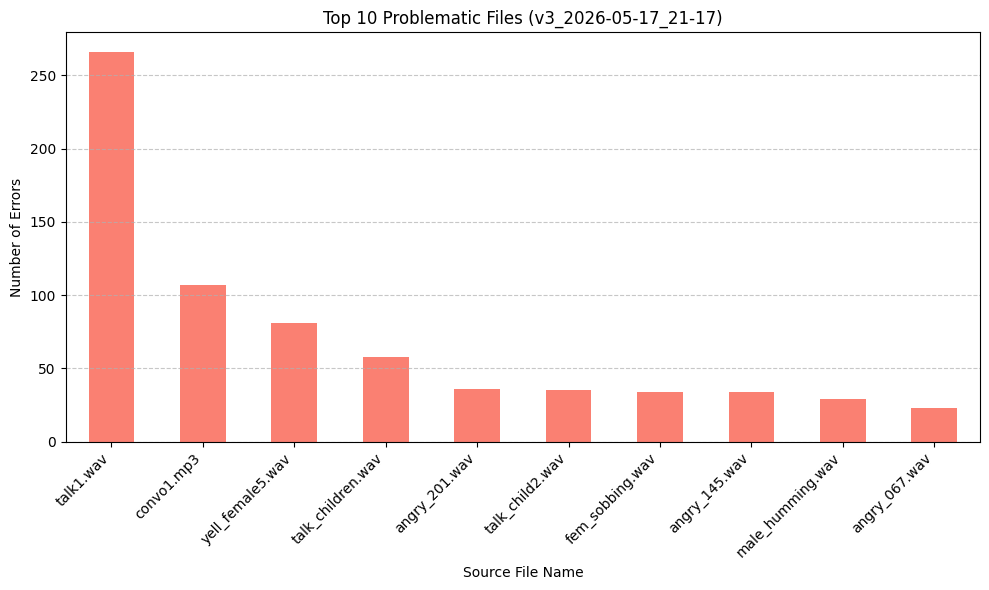

In [5]:
plt.figure(figsize=(10, 6))
err_report["err_nb"].head(10).plot(kind="bar", color="salmon")

plt.title(f"Top 10 Problematic Files ({VERSION})")
plt.ylabel("Number of Errors")
plt.xlabel("Source File Name")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Save chart
plt.tight_layout()  # Ensures all labels are fully visible and not clipped
plt.savefig(BASE_DIR / "top_errors_chart.png")

plt.show()